In [27]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.xpu.is_available():
    device = torch.device("xpu")
elif torch.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import xisf
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import os
import matplotlib.pyplot as plt


Using device: cuda


In [28]:
def xisf_loader(path: str) -> np.ndarray:
    """
    Loads a .xisf file, ensures it's a float array,
    and returns it as a NumPy array in (H, W, C) format.
    """
    try:
        # Load the XISF data
        data = xisf.XISF.read(path)
        
        # --- !! THIS IS THE FIX !! ---
        # .copy() creates a new, writable array in memory for PyTorch
        data = np.asarray(data, dtype=np.float32).copy()
        # --- !! END FIX !! ---

        # PyTorch's ToTensor() transform expects (H, W, C)
        # 1. If data is 2D (H, W), add a channel dim -> (H, W, 1)
        if data.ndim == 2:
            data = data[..., np.newaxis]
        
        # 2. If data is (H, W, 1) or (H, W, 3), it's already correct.
        
        # 3. If data is (C, H, W), transpose it -> (H, W, C)
        elif data.ndim == 3 and data.shape[0] in [1, 3]:
             data = data.transpose((1, 2, 0))

        return data

    except Exception as e:
        print(f"Error loading {path}: {e}")
        return None

print("xisf_loader function defined (with .copy() fix).")

xisf_loader function defined (with .copy() fix).


In [29]:
def detect_color_channels(data_root_path: Path) -> int:
    """
    Detects if the images in the ImageFolder are 1-channel or 3-channel.
    """
    import xisf
    import numpy as np
    
    print(f"Detecting color channels in {data_root_path}...")
    try:
        # Find the first class sub-directory
        first_class_dir = next(p for p in data_root_path.iterdir() if p.is_dir())
        
        # Find the first .xisf file in that directory
        first_xisf_file = next(first_class_dir.rglob('*.xisf'))
        
        print(f"  Checking sample file: {first_xisf_file.name}")
        
        # Load it using our loader
        sample_data = xisf_loader(str(first_xisf_file))
        
        if sample_data.ndim == 3:
            channels = sample_data.shape[2]
            print(f"  Detected {channels} channels.")
            return channels
        elif sample_data.ndim == 2:
            print("  Detected 1 channel (grayscale).")
            return 1
            
    except Exception as e:
        print(f"  !! Warning: Could not detect channels: {e}. Defaulting to 3. !!")
        return 3

In [30]:
# full path DEFAULT_DATA_DIR = Path(os.getcwd()) / 'data' / 'star_cutouts_output' / "stretched_component_cutouts"
DEFAULT_DATA_DIR = Path(os.getcwd()) / 'training_data'
def select_data_directory():
    """
    Opens a pop-up dialog to select the main 'data' directory.
    """
    root = tk.Tk()
    root.withdraw()
    # The initial_dir is now set to your default
    print(f"Please select your main 'data' directory (defaulting to {DEFAULT_DATA_DIR})...")
    dir_path = filedialog.askdirectory(
        title="Select your 'data' directory",
        initialdir=DEFAULT_DATA_DIR 
    )
    if not dir_path:
        print("No directory selected. Exiting.")
        return None
    return Path(dir_path)

In [31]:
transform = transforms.Compose([
    transforms.ToTensor(),
    
    # --- Augmentations for bad data ---
    transforms.RandomAffine(
        degrees=15,          # Randomly rotate
        translate=(0.1, 0.1), # Randomly shift
        scale=(0.8, 1.2)     # Randomly zoom
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    
    # We don't need normalization since we're not using pre-trained weights
])

print("Transforms defined with Augmentations (Affine, Flips).")

Transforms defined with Augmentations (Affine, Flips).


In [32]:
# 1. Run the directory selector
data_dir = DEFAULT_DATA_DIR #select_data_directory()

# --- !! NEW: Define COLOR_CHANNELS variable !! ---
COLOR_CHANNELS = 3 # Default

if data_dir:
    # 2. Define the path to your star cutouts
    star_cutouts_dir = data_dir / 'star_cutouts_output'
    
    # 3. Define the final DATA_ROOT for ImageFolder
    # --- !! CHOOSE YOUR DATASET !! ---
    # (Uncomment the one you want to use)
    
    # --- Option 1: 3-Channel Stretched Color ---
    DATA_ROOT = data_dir #star_cutouts_dir / "stretched_color_cutouts"
    
    # --- Option 2: 1-Channel Stretched Components ---
    # DATA_ROOT = star_cutouts_dir / "stretched_component_cutouts"
    
    # --- Option 3: 3-Channel Linear Color ---
    # DATA_ROOT = star_cutouts_dir / "linear_color_cutouts"
    
    # 4. --- !! NEW: Run Channel Detection !! ---
    if DATA_ROOT.exists():
        COLOR_CHANNELS = detect_color_channels(DATA_ROOT)
        print(f"\nData root successfully set to:")
        print(DATA_ROOT)
        print(f"Detected {COLOR_CHANNELS} color channels.")
    else:
        print(f"!! ERROR: Selected DATA_ROOT does not exist: {DATA_ROOT} !!")
        DATA_ROOT = None

else:
    print("DATA_ROOT not set.")

Detecting color channels in /Storage/Files/practicalML/gitlab/practicalml/training_data...
  Checking sample file: 2024-10-14_02-47-18__-0.00_300.00s_0136_debayered_star_09_x7499_y4770_B_linear.xisf
  Detected 1 channels.

Data root successfully set to:
/Storage/Files/practicalML/gitlab/practicalml/training_data
Detected 1 color channels.


In [33]:
# --- Configuration ---
BATCH_SIZE = 64
NUM_WORKERS = 16 
# ---------------------

# --- !! NEW: Global variable for class count !! ---
NUM_CLASSES = 0
# -------------------------------------------------

if not DATA_ROOT:
    print("DATA_ROOT not set. Please run the cell above (ID: 22a36b50) first.")
else:
    print(f"Loading data from: {DATA_ROOT}")

    # 1. Create the full dataset
    full_dataset = torchvision.datasets.ImageFolder(
        root=str(DATA_ROOT),
        transform=transform,
        loader=xisf_loader,
        is_valid_file=lambda p: p.endswith('.xisf') 
    )
    
    # --- !! NEW: Set the global NUM_CLASSES !! ---
    NUM_CLASSES = len(full_dataset.classes)
    # ---------------------------------------------

    print(f"Found {len(full_dataset)} images in {NUM_CLASSES} classes.")
    print(f"Classes: {full_dataset.class_to_idx}")

    # 2. Split into train, validation, and test sets
    total_size = len(full_dataset)
    train_size = int(0.7 * total_size)
    val_size = int(0.15 * total_size)
    test_size = total_size - train_size - val_size

    print(f"Splitting data into: {train_size} (Train), {val_size} (Val), {test_size} (Test)")
    trainset, valset, testset = random_split(full_dataset, [train_size, val_size, test_size])

    # 3. Create the DataLoaders
    trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    valloader = DataLoader(valset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    print("\nDataLoaders created successfully.")
    print(f"  Train batches: {len(trainloader)}")
    print(f"  Val batches: {len(valloader)}")
    print(f"  Test batches: {len(testloader)}")

Loading data from: /Storage/Files/practicalML/gitlab/practicalml/training_data
Found 24030 images in 4 classes.
Classes: {'focus': 0, 'good': 1, 'tracking': 2, 'wind': 3}
Splitting data into: 16821 (Train), 3604 (Val), 3605 (Test)

DataLoaders created successfully.
  Train batches: 263
  Val batches: 57
  Test batches: 57


In [34]:
from torch.optim.lr_scheduler import StepLR # <-- Import the scheduler

def train_model_resnet(model, trainloader, valloader, testloader, num_epochs=10, lr=0.01):
    """
    Train ResNet from scratch.
    NOW includes a Learning Rate Scheduler.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    
    # --- !! NEW: Add the LR Scheduler !! ---
    # This will reduce the LR by a factor of 0.1 every 7 epochs
    scheduler = StepLR(optimizer, step_size=5, gamma=0.5)
    # --- !! END NEW !! ---

    # Add history lists for test metrics
    train_loss_history, val_loss_history, val_acc_history = [], [], []
    test_loss_history, test_acc_history = [], []

    for epoch in range(num_epochs):
        # ---- Training ----
        model.train()
        running_loss, total, correct = 0.0, 0, 0
        for imgs, labels in trainloader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
        train_loss = running_loss / len(trainloader)
        train_acc = correct / total

        # ---- Validation & Test ----
        model.eval()
        
        # -- Validation --
        running_val_loss, total_val, correct_val = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in valloader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                val_loss = criterion(outputs, labels)
                running_val_loss += val_loss.item()
                _, preds = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (preds == labels).sum().item()
        
        avg_val_loss = running_val_loss / len(valloader)
        val_acc = correct_val / total_val

        # -- Test Loop --
        running_test_loss, total_test, correct_test = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in testloader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                test_loss = criterion(outputs, labels)
                running_test_loss += test_loss.item()
                _, preds = torch.max(outputs, 1)
                total_test += labels.size(0)
                correct_test += (preds == labels).sum().item()

        avg_test_loss = running_test_loss / len(testloader)
        test_acc = correct_test / total_test
        
        # --- !! NEW: Step the scheduler !! ---
        scheduler.step()
        # --- !! END NEW !! ---

        # ---- Save histories ----
        train_loss_history.append(train_loss)
        val_loss_history.append(avg_val_loss)
        val_acc_history.append(val_acc)
        test_loss_history.append(avg_test_loss) 
        test_acc_history.append(test_acc)      

        # --- Updated Print Statement ---
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"Test Loss: {avg_test_loss:.4f} | Test Acc: {test_acc:.4f} | "
              f"LR: {scheduler.get_last_lr()[0]:.6f}") # <-- Show current LR

    return train_loss_history, val_loss_history, val_acc_history, test_loss_history, test_acc_history

In [35]:
def graph_vals(input_data:list[list], plot_names:list, title:str, x_label:str, y_label:str):
    x_axis = range(1, len(input_data[0]) + 1)
    plt.figure(figsize=(10, 6))
    for line, label in zip(input_data, plot_names):
        plt.plot(x_axis, line, marker='o', linestyle='-', label=label)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(True)
    plt.legend()
    plt.show()

def save_model(model_name:str, root_dir, model, class_names, num_classes, color_channels):
    # --- Configuration ---
    MODEL_FILENAME = f"{model_name}.pth"
    SAVE_PATH = root_dir / MODEL_FILENAME
    # ---------------------

    print(f"Saving model to: {root_dir}")

    # Save a dictionary containing the weights AND the config
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_name': model_name, # or 'resnet18', etc.
        'num_classes': num_classes,
        'input_channels': color_channels,
        'class_names': class_names
    }, SAVE_PATH)

    print("Model saved successfully.")

In [35]:
# --- Configuration ---
LEARNING_RATE = 0.01 # <-- Good starting LR for transfer learning
NUM_EPOCHS = 25
# ---------------------

if NUM_CLASSES == 0:
    print("!! ERROR: NUM_CLASSES is 0. Please run the DataLoader cell first. !!")
else:
    # 1. Load the PRE-TRAINED ResNet-18
    resnet_transfer = torchvision.models.resnet18(
        weights=torchvision.models.ResNet18_Weights.DEFAULT
    )
    
    # --- !! ADVANCED: Adapt conv1 for 1-Channel !! ---
    if COLOR_CHANNELS == 1:
        print("Customizing ResNet-18 for 1-channel input with pre-trained weights.")
        
        # Get the original 3-channel weights
        original_weights = resnet_transfer.conv1.weight.data
        
        # Create a new 1-channel conv layer
        new_conv1 = nn.Conv2d(
            1, 64, 
            kernel_size=7, 
            stride=2, 
            padding=3, 
            bias=False
        )
        
        # Average the 3-channel weights to create new 1-channel weights
        new_conv1.weight.data = torch.mean(original_weights, dim=1, keepdim=True)
        
        # Replace the model's conv1 layer
        resnet_transfer.conv1 = new_conv1

    # --- !! 2. Customize the final layer !! ---
    # Freeze all layers
    for param in resnet_transfer.parameters():
        param.requires_grad = False
    
    # Replace the final layer and make sure it's unfrozen
    num_ftrs = resnet_transfer.fc.in_features
    resnet_transfer.fc = nn.Linear(num_ftrs, NUM_CLASSES)
    
    # --- !! END CUSTOMIZATION !! ---
    
    resnet_auto = resnet_transfer.to(device)
    resnet_auto.eval()

    print(f"Training ResNet-18 (Transfer Learning) for {NUM_CLASSES} classes on {COLOR_CHANNELS}-channel images.")

    # 3. Train the model
    (
        train_loss_resnet, 
        val_loss_resnet, 
        val_acc_resnet, 
        test_loss_resnet,
        test_acc_resnet
    ) = train_model_resnet(
        resnet_auto, 
        trainloader, 
        valloader, 
        testloader,
        num_epochs=NUM_EPOCHS, 
        lr=LEARNING_RATE
    )

    print("Training complete.")
    save_model("Pre-Trained_Resnet-18", DATA_ROOT, resnet_auto, full_dataset.classes, NUM_CLASSES, COLOR_CHANNELS)

Customizing ResNet-18 for 1-channel input with pre-trained weights.
Training ResNet-18 (Transfer Learning) for 4 classes on 1-channel images.
Epoch 1/25 | Train Loss: 0.6587 | Train Acc: 0.7517 | Val Loss: 0.5227 | Val Acc: 0.8060 | Test Loss: 0.5298 | Test Acc: 0.7945 | LR: 0.010000
Epoch 2/25 | Train Loss: 0.5496 | Train Acc: 0.7939 | Val Loss: 0.5160 | Val Acc: 0.8038 | Test Loss: 0.5169 | Test Acc: 0.7997 | LR: 0.010000
Epoch 3/25 | Train Loss: 0.5369 | Train Acc: 0.7987 | Val Loss: 0.5406 | Val Acc: 0.8011 | Test Loss: 0.5074 | Test Acc: 0.8119 | LR: 0.010000
Epoch 4/25 | Train Loss: 0.5239 | Train Acc: 0.8030 | Val Loss: 0.5561 | Val Acc: 0.7955 | Test Loss: 0.5509 | Test Acc: 0.7878 | LR: 0.010000
Epoch 5/25 | Train Loss: 0.5270 | Train Acc: 0.8021 | Val Loss: 0.4815 | Val Acc: 0.8255 | Test Loss: 0.4686 | Test Acc: 0.8186 | LR: 0.005000
Epoch 6/25 | Train Loss: 0.5034 | Train Acc: 0.8119 | Val Loss: 0.4604 | Val Acc: 0.8282 | Test Loss: 0.4659 | Test Acc: 0.8211 | LR: 0.005000


In [38]:
resnet_transfer = torchvision.models.resnet18(
    weights=torchvision.models.ResNet18_Weights.DEFAULT
)
resnet_transfer.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

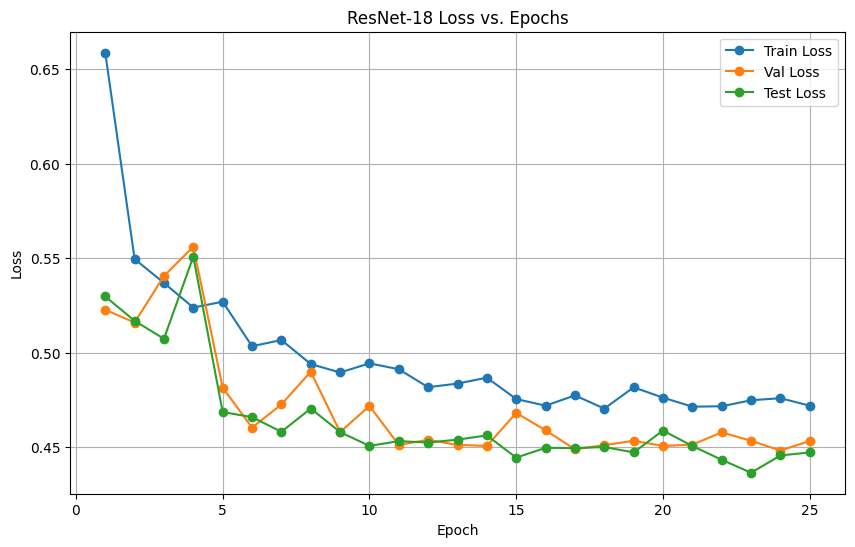

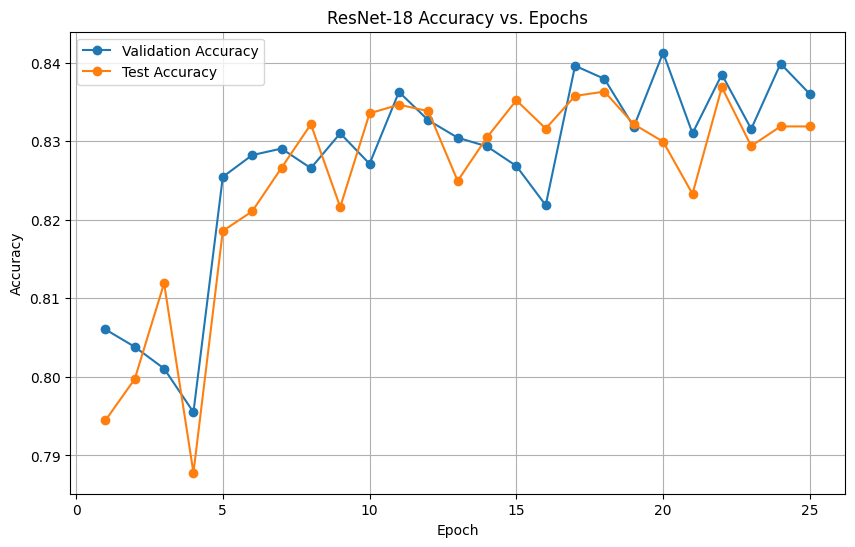

In [39]:
# --- Plot 1: Loss ---
loss_plots = [train_loss_resnet, val_loss_resnet, test_loss_resnet]
loss_labels = ["Train Loss", "Val Loss", "Test Loss"]
graph_vals(loss_plots, loss_labels, "ResNet-18 Loss vs. Epochs", "Epoch", "Loss")

# --- Plot 2: Accuracy ---
acc_plots = [val_acc_resnet, test_acc_resnet]
acc_labels = ["Validation Accuracy", "Test Accuracy"]
graph_vals(acc_plots, acc_labels, "ResNet-18 Accuracy vs. Epochs", "Epoch", "Accuracy")



In [40]:
# --- Configuration ---
LEARNING_RATE = 0.01  # <-- Lowered to 0.01 for more stable transfer learning
NUM_EPOCHS = 25
# ---------------------

if NUM_CLASSES == 0:
    print("!! ERROR: NUM_CLASSES is 0. Please run the DataLoader cell first. !!")
else:
    # 1. Load the PRE-TRAINED MobileNetV2
    # This is a smaller, faster model than ResNet-18
    model_transfer = torchvision.models.mobilenet_v2(
        weights=torchvision.models.MobileNet_V2_Weights.DEFAULT
    )

    # --- !! 2. ADVANCED: Adapt conv1 for 1-Channel !! ---
    if COLOR_CHANNELS == 1:
        print(f"Customizing MobileNetV2 for {COLOR_CHANNELS}-channel input with pre-trained weights.")
        
        # Get the original 3-channel weights from the first layer
        original_conv = model_transfer.features[0][0]
        original_weights = original_conv.weight.data
        
        # Create a new 1-channel conv layer
        new_conv1 = nn.Conv2d(
            1, # in_channels
            original_conv.out_channels, 
            kernel_size=original_conv.kernel_size, 
            stride=original_conv.stride, 
            padding=original_conv.padding, 
            bias=False
        )
        
        # Average the 3-channel weights to create new 1-channel weights
        new_conv1.weight.data = torch.mean(original_weights, dim=1, keepdim=True)
        
        # Replace the model's first conv layer
        model_transfer.features[0][0] = new_conv1

    # --- !! 3. Customize the final layer !! ---
    # Freeze all layers
    for param in model_transfer.parameters():
        param.requires_grad = False
    
    # Replace the final classifier layer and make sure it's unfrozen
    num_ftrs = model_transfer.classifier[1].in_features
    model_transfer.classifier[1] = nn.Linear(num_ftrs, NUM_CLASSES)
    
    # --- !! END CUSTOMIZATION !! ---
    
    resnet_auto = model_transfer.to(device) # Keep var name for compatibility
    resnet_auto.eval()

    print(f"Training MobileNetV2 (Transfer Learning) for {NUM_CLASSES} classes on {COLOR_CHANNELS}-channel images.")

    # 4. Train the model
    (
        train_loss_resnet, 
        val_loss_resnet, 
        val_acc_resnet, 
        test_loss_resnet,
        test_acc_resnet
    ) = train_model_resnet(
        resnet_auto,  # Pass the new model
        trainloader, 
        valloader, 
        testloader,
        num_epochs=NUM_EPOCHS, 
        lr=LEARNING_RATE
    )

    print("Training complete.")
    save_model("Pre-Trained_MobileNetV2", DATA_ROOT, resnet_auto, full_dataset.classes, NUM_CLASSES, COLOR_CHANNELS)

Customizing MobileNetV2 for 1-channel input with pre-trained weights.
Training MobileNetV2 (Transfer Learning) for 4 classes on 1-channel images.
Epoch 1/25 | Train Loss: 0.7081 | Train Acc: 0.7467 | Val Loss: 0.5508 | Val Acc: 0.7986 | Test Loss: 0.5566 | Test Acc: 0.7931 | LR: 0.010000
Epoch 2/25 | Train Loss: 0.5485 | Train Acc: 0.8039 | Val Loss: 0.5013 | Val Acc: 0.8291 | Test Loss: 0.4890 | Test Acc: 0.8280 | LR: 0.010000
Epoch 3/25 | Train Loss: 0.5167 | Train Acc: 0.8149 | Val Loss: 0.4678 | Val Acc: 0.8382 | Test Loss: 0.4654 | Test Acc: 0.8338 | LR: 0.010000
Epoch 4/25 | Train Loss: 0.5043 | Train Acc: 0.8171 | Val Loss: 0.4544 | Val Acc: 0.8360 | Test Loss: 0.4641 | Test Acc: 0.8277 | LR: 0.010000
Epoch 5/25 | Train Loss: 0.4908 | Train Acc: 0.8186 | Val Loss: 0.4709 | Val Acc: 0.8338 | Test Loss: 0.4591 | Test Acc: 0.8341 | LR: 0.005000
Epoch 6/25 | Train Loss: 0.4921 | Train Acc: 0.8192 | Val Loss: 0.4581 | Val Acc: 0.8357 | Test Loss: 0.4414 | Test Acc: 0.8355 | LR: 0.005

In [41]:
model_transfer = torchvision.models.mobilenet_v2(
    weights=torchvision.models.MobileNet_V2_Weights.DEFAULT
)
model_transfer.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

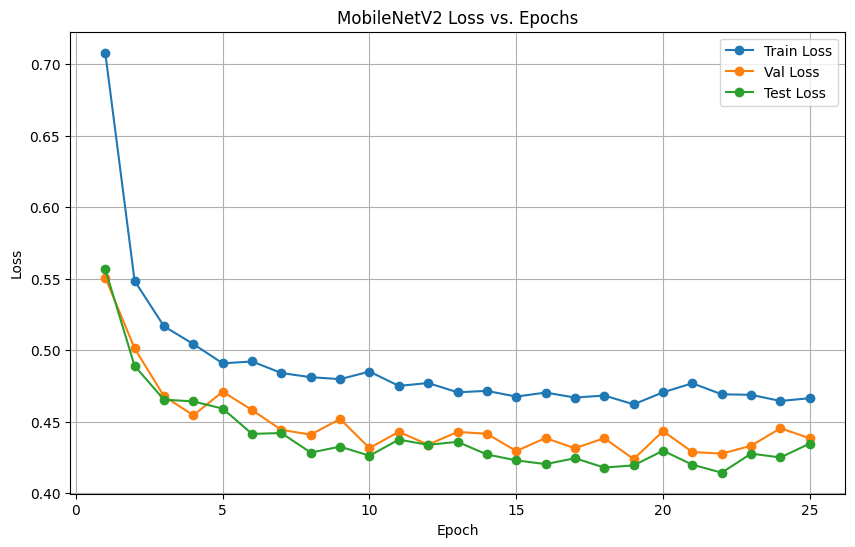

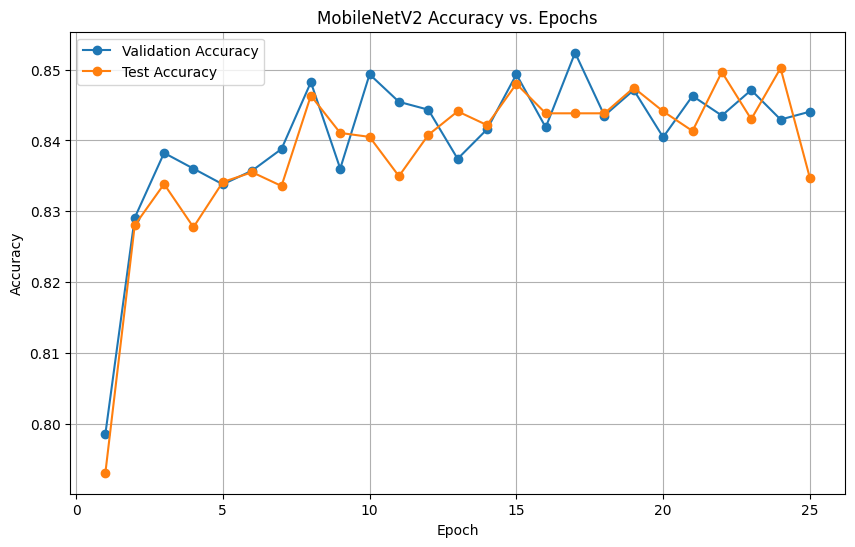

In [42]:
# --- Plot 1: Loss ---
loss_plots = [train_loss_resnet, val_loss_resnet, test_loss_resnet]
loss_labels = ["Train Loss", "Val Loss", "Test Loss"]
graph_vals(loss_plots, loss_labels, "MobileNetV2 Loss vs. Epochs", "Epoch", "Loss")

# --- Plot 2: Accuracy ---
acc_plots = [val_acc_resnet, test_acc_resnet]
acc_labels = ["Validation Accuracy", "Test Accuracy"]
graph_vals(acc_plots, acc_labels, "MobileNetV2 Accuracy vs. Epochs", "Epoch", "Accuracy")

In [43]:
# --- Configuration ---
LEARNING_RATE = 0.01  # <-- WAS 0.05. This is the critical fix for stability.
NUM_EPOCHS = 25
# ---------------------

# --- !! NEW: Weight Initialization Function !! ---
# This helps the model train better from scratch
def weights_init(m):
    if isinstance(m, nn.Conv2d):
        # Kaiming He initialization is designed for ReLU activations
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)
# --- !! END NEW !! ---

if NUM_CLASSES == 0:
    print("!! ERROR: NUM_CLASSES is 0. Please run the DataLoader cell (ID: 37fe5b4f) first. !!")
else:
    # 1. Build the 1-channel model from scratch
    # (We are using MobileNetV2 as it's lighter, but ResNet-18 would also work)
    resnet_auto = torchvision.models.mobilenet_v2(weights=None, num_classes=NUM_CLASSES)
    
    # Customize for 1-channel
    if COLOR_CHANNELS == 1:
        print(f"Customizing MobileNetV2 for {COLOR_CHANNELS}-channel input.")
        original_conv = resnet_auto.features[0][0]
        resnet_auto.features[0][0] = nn.Conv2d(
            1, original_conv.out_channels, 
            kernel_size=original_conv.kernel_size, stride=original_conv.stride, 
            padding=original_conv.padding, bias=False
        )
    
    # Customize final layer
    num_ftrs = resnet_auto.classifier[1].in_features
    resnet_auto.classifier[1] = nn.Linear(num_ftrs, NUM_CLASSES)
    
    # --- !! NEW: Apply the custom weights !! ---
    print("Applying Kaiming He weight initialization...")
    resnet_auto.apply(weights_init)
    # --- !! END NEW !! ---
    
    resnet_auto = resnet_auto.to(device) 

    print(f"Training MobileNetV2 (from scratch) for {NUM_CLASSES} classes on {COLOR_CHANNELS}-channel images.")

    # 3. Train the model
    (
        train_loss_resnet, 
        val_loss_resnet, 
        val_acc_resnet, 
        test_loss_resnet,
        test_acc_resnet
    ) = train_model_resnet(
        resnet_auto,
        trainloader, 
        valloader, 
        testloader,
        num_epochs=NUM_EPOCHS, 
        lr=LEARNING_RATE  # <-- Using the new, lower LR
    )

    print("Training complete.")
    save_model("Scratch_MobileNetV2", DATA_ROOT, resnet_auto, full_dataset.classes, NUM_CLASSES, COLOR_CHANNELS)

Customizing MobileNetV2 for 1-channel input.
Applying Kaiming He weight initialization...
Training MobileNetV2 (from scratch) for 4 classes on 1-channel images.
Epoch 1/25 | Train Loss: 0.7541 | Train Acc: 0.7223 | Val Loss: 0.6089 | Val Acc: 0.7744 | Test Loss: 0.5955 | Test Acc: 0.7667 | LR: 0.010000
Epoch 2/25 | Train Loss: 0.5767 | Train Acc: 0.7796 | Val Loss: 0.5495 | Val Acc: 0.7941 | Test Loss: 0.5509 | Test Acc: 0.7881 | LR: 0.010000
Epoch 3/25 | Train Loss: 0.4921 | Train Acc: 0.8181 | Val Loss: 0.4129 | Val Acc: 0.8527 | Test Loss: 0.4034 | Test Acc: 0.8599 | LR: 0.010000
Epoch 4/25 | Train Loss: 0.4141 | Train Acc: 0.8527 | Val Loss: 0.4844 | Val Acc: 0.8202 | Test Loss: 0.4729 | Test Acc: 0.8305 | LR: 0.010000
Epoch 5/25 | Train Loss: 0.3803 | Train Acc: 0.8609 | Val Loss: 0.4777 | Val Acc: 0.8166 | Test Loss: 0.4639 | Test Acc: 0.8227 | LR: 0.005000
Epoch 6/25 | Train Loss: 0.3219 | Train Acc: 0.8825 | Val Loss: 0.2831 | Val Acc: 0.8990 | Test Loss: 0.2816 | Test Acc: 0.8

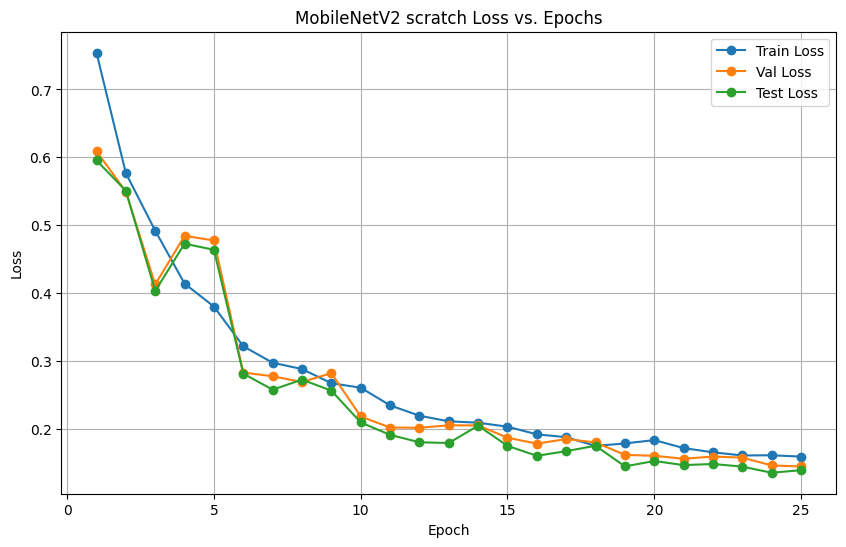

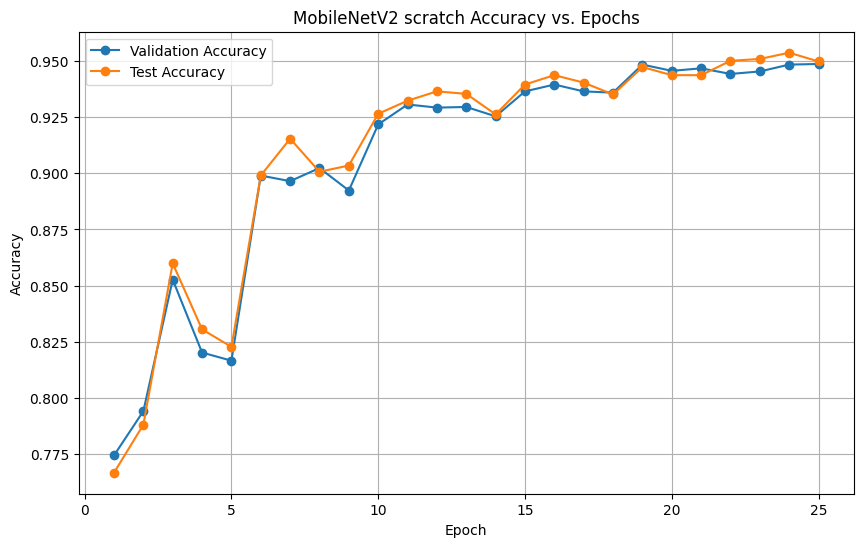

In [44]:
# --- Plot 1: Loss ---
loss_plots = [train_loss_resnet, val_loss_resnet, test_loss_resnet]
loss_labels = ["Train Loss", "Val Loss", "Test Loss"]
graph_vals(loss_plots, loss_labels, "MobileNetV2 scratch Loss vs. Epochs", "Epoch", "Loss")

# --- Plot 2: Accuracy ---
acc_plots = [val_acc_resnet, test_acc_resnet]
acc_labels = ["Validation Accuracy", "Test Accuracy"]
graph_vals(acc_plots, acc_labels, "MobileNetV2 scratch Accuracy vs. Epochs", "Epoch", "Accuracy")

In [45]:
# --- Configuration ---
LEARNING_RATE = 0.01 
NUM_EPOCHS = 25
# ---------------------

# --- Weight Initialization Function ---
def weights_init(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, 0, 0.01)
        nn.init.constant_(m.bias, 0)

if NUM_CLASSES == 0:
    print("!! ERROR: NUM_CLASSES is 0. Please run the DataLoader cell first. !!")
else:
    # 1. Load ResNet-18 structure FROM SCRATCH
    resnet_auto = torchvision.models.resnet18(weights=None)

    # 2. Customize Input Layer for 1-Channel
    if COLOR_CHANNELS == 1:
        print(f"Customizing ResNet-18 for {COLOR_CHANNELS}-channel input.")
        
        # In ResNet, the first conv is 'conv1'
        # Original: nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        resnet_auto.conv1 = nn.Conv2d(
            1, # in_channels
            64, # out_channels (same as original)
            kernel_size=7, 
            stride=2, 
            padding=3, 
            bias=False
        )

    # 3. Customize Final Layer
    # In ResNet, the classifier is 'fc'
    num_ftrs = resnet_auto.fc.in_features
    resnet_auto.fc = nn.Linear(num_ftrs, NUM_CLASSES)
    
    # 4. Apply Kaiming He Initialization
    print("Applying Kaiming He weight initialization...")
    resnet_auto.apply(weights_init)
    
    resnet_auto = resnet_auto.to(device) 

    print(f"Training ResNet-18 (from scratch) for {NUM_CLASSES} classes on {COLOR_CHANNELS}-channel images.")

    # 5. Train the model
    (
        train_loss_resnet, 
        val_loss_resnet, 
        val_acc_resnet, 
        test_loss_resnet,
        test_acc_resnet
    ) = train_model_resnet(
        resnet_auto,
        trainloader, 
        valloader, 
        testloader,
        num_epochs=NUM_EPOCHS, 
        lr=LEARNING_RATE
    )

    print("Training complete.")
    save_model("Scratch_ResNet-18", DATA_ROOT, resnet_auto, full_dataset.classes, NUM_CLASSES, COLOR_CHANNELS)

Customizing ResNet-18 for 1-channel input.
Applying Kaiming He weight initialization...
Training ResNet-18 (from scratch) for 4 classes on 1-channel images.
Epoch 1/25 | Train Loss: 0.7446 | Train Acc: 0.7242 | Val Loss: 1.4008 | Val Acc: 0.6676 | Test Loss: 1.3767 | Test Acc: 0.6627 | LR: 0.010000
Epoch 2/25 | Train Loss: 0.6559 | Train Acc: 0.7526 | Val Loss: 3.2983 | Val Acc: 0.6299 | Test Loss: 3.0476 | Test Acc: 0.6239 | LR: 0.010000
Epoch 3/25 | Train Loss: 0.5868 | Train Acc: 0.7760 | Val Loss: 0.5529 | Val Acc: 0.7902 | Test Loss: 0.5418 | Test Acc: 0.7892 | LR: 0.010000
Epoch 4/25 | Train Loss: 0.5143 | Train Acc: 0.8058 | Val Loss: 0.5920 | Val Acc: 0.7936 | Test Loss: 0.6038 | Test Acc: 0.7845 | LR: 0.010000
Epoch 5/25 | Train Loss: 0.4463 | Train Acc: 0.8314 | Val Loss: 0.6947 | Val Acc: 0.7431 | Test Loss: 0.6945 | Test Acc: 0.7456 | LR: 0.005000
Epoch 6/25 | Train Loss: 0.3884 | Train Acc: 0.8571 | Val Loss: 0.4142 | Val Acc: 0.8330 | Test Loss: 0.4085 | Test Acc: 0.8469 

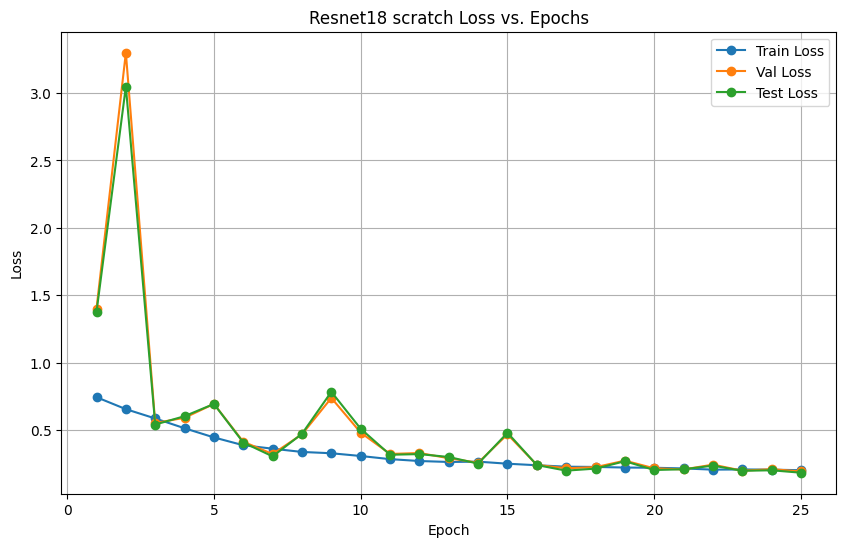

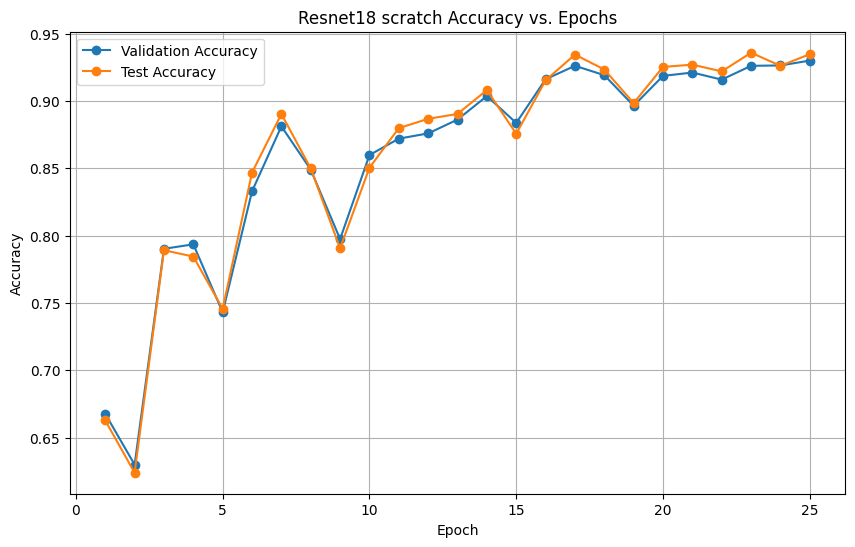

In [46]:
# --- Plot 1: Loss ---
loss_plots = [train_loss_resnet, val_loss_resnet, test_loss_resnet]
loss_labels = ["Train Loss", "Val Loss", "Test Loss"]
graph_vals(loss_plots, loss_labels, "Resnet18 scratch Loss vs. Epochs", "Epoch", "Loss")

# --- Plot 2: Accuracy ---
acc_plots = [val_acc_resnet, test_acc_resnet]
acc_labels = ["Validation Accuracy", "Test Accuracy"]
graph_vals(acc_plots, acc_labels, "Resnet18 scratch Accuracy vs. Epochs", "Epoch", "Accuracy")

In [47]:
# --- Configuration ---
LEARNING_RATE = 0.01 
NUM_EPOCHS = 25
# ---------------------

# --- Weight Initialization Function ---
def weights_init(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, 0, 0.01)
        nn.init.constant_(m.bias, 0)

if NUM_CLASSES == 0:
    print("!! ERROR: NUM_CLASSES is 0. Please run the DataLoader cell first. !!")
else:
    # 1. Load ShuffleNet V2 structure FROM SCRATCH
    # (x1.0 is the standard width multiplier)
    resnet_auto = torchvision.models.shufflenet_v2_x1_0(weights=None)

    # 2. Customize Input Layer for 1-Channel
    if COLOR_CHANNELS == 1:
        print(f"Customizing ShuffleNetV2 for {COLOR_CHANNELS}-channel input.")
        
        # In ShuffleNet, 'conv1' is a Sequential block: [Conv2d, BatchNorm, ReLU]
        # The actual convolution is at index 0.
        original_conv = resnet_auto.conv1[0]
        
        # Create new 1-channel layer using the original's settings
        new_conv = nn.Conv2d(
            1, # in_channels
            original_conv.out_channels, 
            kernel_size=original_conv.kernel_size, 
            stride=original_conv.stride, 
            padding=original_conv.padding, 
            bias=False
        )
        
        # Replace the layer in the sequence
        resnet_auto.conv1[0] = new_conv

    # 3. Customize Final Layer
    # In ShuffleNet, the classifier is 'fc'
    num_ftrs = resnet_auto.fc.in_features
    resnet_auto.fc = nn.Linear(num_ftrs, NUM_CLASSES)
    
    # 4. Apply Kaiming He Initialization
    print("Applying Kaiming He weight initialization...")
    resnet_auto.apply(weights_init)
    
    resnet_auto = resnet_auto.to(device) 

    print(f"Training ShuffleNetV2 (from scratch) for {NUM_CLASSES} classes on {COLOR_CHANNELS}-channel images.")

    # 5. Train the model
    (
        train_loss_resnet, 
        val_loss_resnet, 
        val_acc_resnet, 
        test_loss_resnet,
        test_acc_resnet
    ) = train_model_resnet(
        resnet_auto,
        trainloader, 
        valloader, 
        testloader,
        num_epochs=NUM_EPOCHS, 
        lr=LEARNING_RATE
    )

    print("Training complete.")
    save_model("Scratch_ShuffleNetV2", DATA_ROOT, resnet_auto, full_dataset.classes, NUM_CLASSES, COLOR_CHANNELS)

Customizing ShuffleNetV2 for 1-channel input.
Applying Kaiming He weight initialization...
Training ShuffleNetV2 (from scratch) for 4 classes on 1-channel images.
Epoch 1/25 | Train Loss: 0.8275 | Train Acc: 0.6950 | Val Loss: 0.8179 | Val Acc: 0.7214 | Test Loss: 0.8116 | Test Acc: 0.7168 | LR: 0.010000
Epoch 2/25 | Train Loss: 0.6493 | Train Acc: 0.7592 | Val Loss: 0.6676 | Val Acc: 0.7411 | Test Loss: 0.6581 | Test Acc: 0.7393 | LR: 0.010000
Epoch 3/25 | Train Loss: 0.5932 | Train Acc: 0.7734 | Val Loss: 0.5834 | Val Acc: 0.7825 | Test Loss: 0.5871 | Test Acc: 0.7792 | LR: 0.010000
Epoch 4/25 | Train Loss: 0.5450 | Train Acc: 0.7944 | Val Loss: 0.6135 | Val Acc: 0.7647 | Test Loss: 0.6052 | Test Acc: 0.7601 | LR: 0.010000
Epoch 5/25 | Train Loss: 0.5114 | Train Acc: 0.8101 | Val Loss: 0.4638 | Val Acc: 0.8355 | Test Loss: 0.4602 | Test Acc: 0.8316 | LR: 0.005000
Epoch 6/25 | Train Loss: 0.4375 | Train Acc: 0.8431 | Val Loss: 0.4834 | Val Acc: 0.8271 | Test Loss: 0.4678 | Test Acc: 0

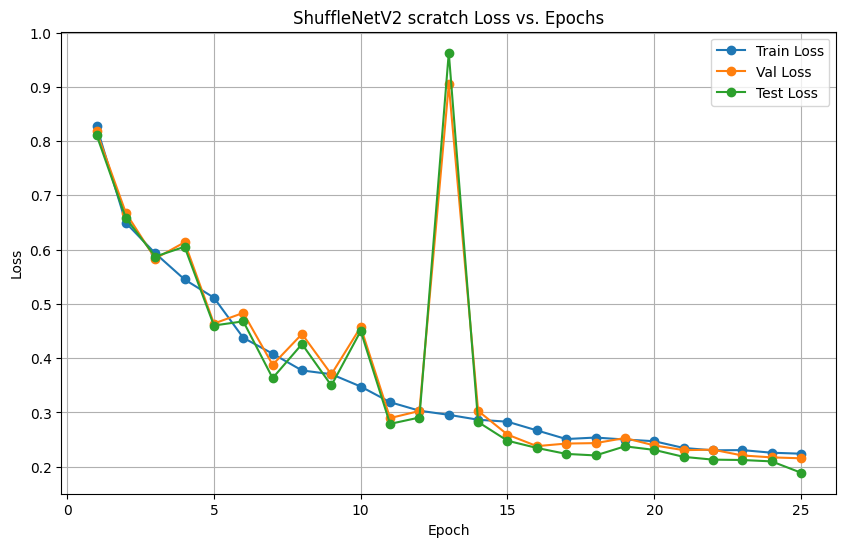

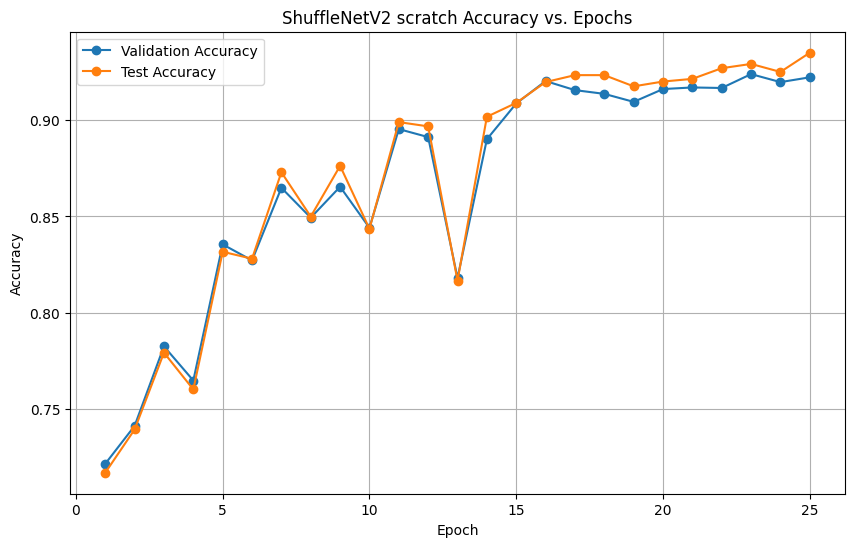

In [48]:
# --- Plot 1: Loss ---
loss_plots = [train_loss_resnet, val_loss_resnet, test_loss_resnet]
loss_labels = ["Train Loss", "Val Loss", "Test Loss"]
graph_vals(loss_plots, loss_labels, "ShuffleNetV2 scratch Loss vs. Epochs", "Epoch", "Loss")

# --- Plot 2: Accuracy ---
acc_plots = [val_acc_resnet, test_acc_resnet]
acc_labels = ["Validation Accuracy", "Test Accuracy"]
graph_vals(acc_plots, acc_labels, "ShuffleNetV2 scratch Accuracy vs. Epochs", "Epoch", "Accuracy")

In [10]:
# --- Configuration ---
LEARNING_RATE = 0.01 
NUM_EPOCHS = 25
# ---------------------

# --- Weight Initialization Function ---
def weights_init(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, 0, 0.01)
        nn.init.constant_(m.bias, 0)

if NUM_CLASSES == 0:
    print("!! ERROR: NUM_CLASSES is 0. Please run the DataLoader cell first. !!")
else:
    # 1. Load EfficientNetV2_S structure FROM SCRATCH
    resnet_auto = torchvision.models.efficientnet_v2_s(weights=None)

    # 2. Customize Input Layer for 1-Channel
    if COLOR_CHANNELS == 1:
        print(f"Customizing EfficientNetV2 for {COLOR_CHANNELS}-channel input.")
        
        # In EfficientNet, the first convolution is inside the 'features' block
        original_conv = resnet_auto.features[0][0]
        
        # Create new 1-channel layer using original settings
        resnet_auto.features[0][0] = nn.Conv2d(
            1, # in_channels
            original_conv.out_channels, 
            kernel_size=original_conv.kernel_size, 
            stride=original_conv.stride, 
            padding=original_conv.padding, 
            bias=False
        )

    # 3. Customize Final Layer
    # The classifier is a Sequential block: [Dropout, Linear]
    num_ftrs = resnet_auto.classifier[1].in_features
    resnet_auto.classifier[1] = nn.Linear(num_ftrs, NUM_CLASSES)
    
    # 4. Apply Kaiming He Initialization
    print("Applying Kaiming He weight initialization...")
    resnet_auto.apply(weights_init)
    
    resnet_auto = resnet_auto.to(device) 

    print(f"Training EfficientNetV2 (from scratch) for {NUM_CLASSES} classes on {COLOR_CHANNELS}-channel images.")

    # 5. Train the model
    (
        train_loss_resnet, 
        val_loss_resnet, 
        val_acc_resnet, 
        test_loss_resnet,
        test_acc_resnet
    ) = train_model_resnet(
        resnet_auto,
        trainloader, 
        valloader, 
        testloader,
        num_epochs=NUM_EPOCHS, 
        lr=LEARNING_RATE
    )

    print("Training complete.")
    save_model("Scratch_EfficientNetV2", DATA_ROOT, resnet_auto, full_dataset.classes, NUM_CLASSES, COLOR_CHANNELS)

Customizing EfficientNetV2 for 1-channel input.
Applying Kaiming He weight initialization...
Training EfficientNetV2 (from scratch) for 4 classes on 1-channel images.
Epoch 1/25 | Train Loss: 0.7805 | Train Acc: 0.7237 | Val Loss: 0.6749 | Val Acc: 0.7586 | Test Loss: 0.6767 | Test Acc: 0.7448 | LR: 0.010000
Epoch 2/25 | Train Loss: 0.6296 | Train Acc: 0.7710 | Val Loss: 0.5875 | Val Acc: 0.7836 | Test Loss: 0.6101 | Test Acc: 0.7720 | LR: 0.010000
Epoch 3/25 | Train Loss: 0.5515 | Train Acc: 0.7871 | Val Loss: 0.4800 | Val Acc: 0.8224 | Test Loss: 0.4819 | Test Acc: 0.8130 | LR: 0.010000
Epoch 4/25 | Train Loss: 0.4624 | Train Acc: 0.8277 | Val Loss: 0.3783 | Val Acc: 0.8627 | Test Loss: 0.3992 | Test Acc: 0.8519 | LR: 0.010000
Epoch 5/25 | Train Loss: 0.4109 | Train Acc: 0.8462 | Val Loss: 0.3919 | Val Acc: 0.8479 | Test Loss: 0.3953 | Test Acc: 0.8516 | LR: 0.005000
Epoch 6/25 | Train Loss: 0.3372 | Train Acc: 0.8746 | Val Loss: 0.3099 | Val Acc: 0.8854 | Test Loss: 0.2950 | Test Ac

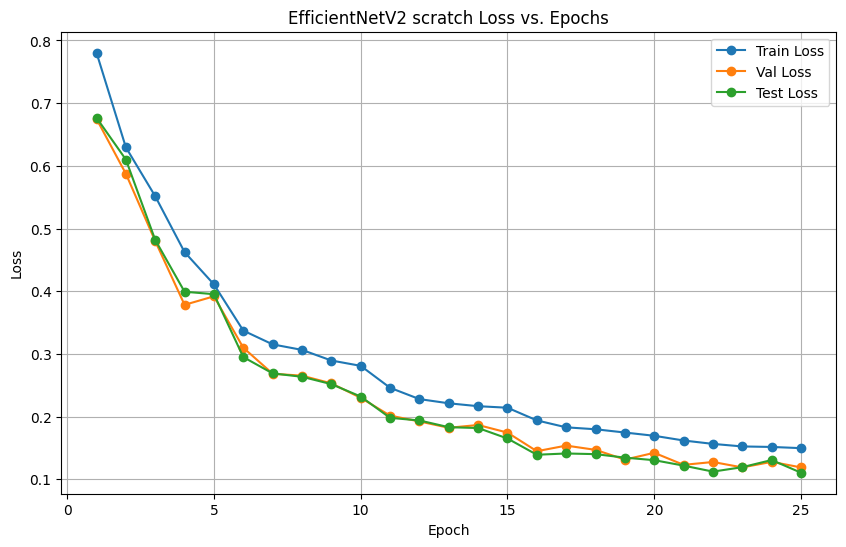

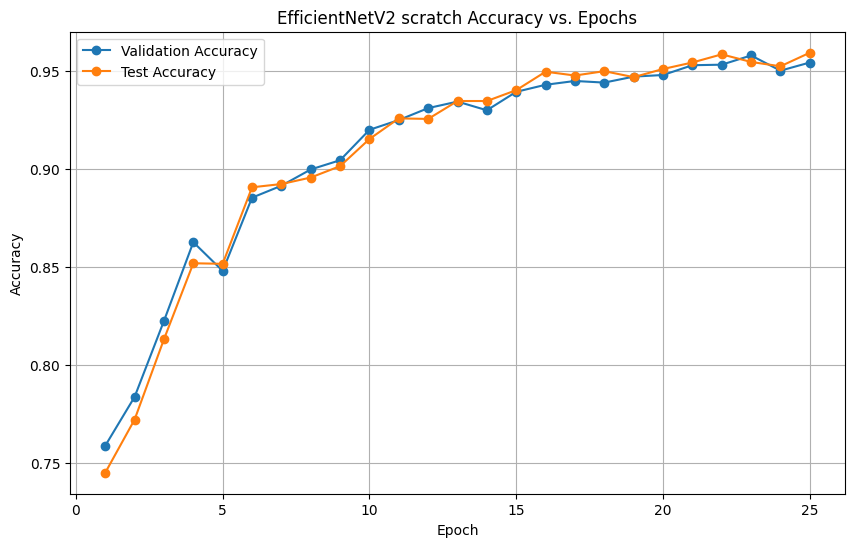

In [11]:
# --- Plot 1: Loss ---
loss_plots = [train_loss_resnet, val_loss_resnet, test_loss_resnet]
loss_labels = ["Train Loss", "Val Loss", "Test Loss"]
graph_vals(loss_plots, loss_labels, "EfficientNetV2 scratch Loss vs. Epochs", "Epoch", "Loss")

# --- Plot 2: Accuracy ---
acc_plots = [val_acc_resnet, test_acc_resnet]
acc_labels = ["Validation Accuracy", "Test Accuracy"]
graph_vals(acc_plots, acc_labels, "EfficientNetV2 scratch Accuracy vs. Epochs", "Epoch", "Accuracy")

In [36]:
# --- Configuration ---
LEARNING_RATE = 0.01  # Keep the stable rate
NUM_EPOCHS = 25
# ---------------------

# --- Weight Initialization Function ---
def weights_init(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, 0, 0.01)
        nn.init.constant_(m.bias, 0)

if NUM_CLASSES == 0:
    print("!! ERROR: NUM_CLASSES is 0. Please run the DataLoader cell first. !!")
else:
    # 1. Load DenseNet-121 structure FROM SCRATCH
    resnet_auto = torchvision.models.densenet121(weights=None)

    # 2. Customize Input Layer for 1-Channel
    if COLOR_CHANNELS == 1:
        print(f"Customizing DenseNet-121 for {COLOR_CHANNELS}-channel input.")
        
        # In DenseNet, the first conv is 'features.conv0'
        original_conv = resnet_auto.features.conv0
        
        # Create new 1-channel layer
        resnet_auto.features.conv0 = nn.Conv2d(
            1, # in_channels
            original_conv.out_channels, 
            kernel_size=original_conv.kernel_size, 
            stride=original_conv.stride, 
            padding=original_conv.padding, 
            bias=False
        )

    # 3. Customize Final Layer
    # In DenseNet, the classifier is a single Linear layer named 'classifier'
    num_ftrs = resnet_auto.classifier.in_features
    resnet_auto.classifier = nn.Linear(num_ftrs, NUM_CLASSES)
    
    # 4. Apply Kaiming He Initialization
    print("Applying Kaiming He weight initialization...")
    resnet_auto.apply(weights_init)
    
    resnet_auto = resnet_auto.to(device) 

    print(f"Training DenseNet-121 (from scratch) for {NUM_CLASSES} classes on {COLOR_CHANNELS}-channel images.")

    # 5. Train the model
    (
        train_loss_resnet, 
        val_loss_resnet, 
        val_acc_resnet, 
        test_loss_resnet,
        test_acc_resnet
    ) = train_model_resnet(
        resnet_auto,
        trainloader, 
        valloader, 
        testloader,
        num_epochs=NUM_EPOCHS, 
        lr=LEARNING_RATE
    )

    print("Training complete.")
    save_model("Scratch_DenseNet-121", DATA_ROOT, resnet_auto, full_dataset.classes, NUM_CLASSES, COLOR_CHANNELS)

Customizing DenseNet-121 for 1-channel input.
Applying Kaiming He weight initialization...
Training DenseNet-121 (from scratch) for 4 classes on 1-channel images.
Epoch 1/25 | Train Loss: 0.7296 | Train Acc: 0.7256 | Val Loss: 0.5777 | Val Acc: 0.7783 | Test Loss: 0.5993 | Test Acc: 0.7725 | LR: 0.010000
Epoch 2/25 | Train Loss: 0.5858 | Train Acc: 0.7797 | Val Loss: 8.8844 | Val Acc: 0.7131 | Test Loss: 9.2872 | Test Acc: 0.7024 | LR: 0.010000
Epoch 3/25 | Train Loss: 0.4927 | Train Acc: 0.8174 | Val Loss: 0.5368 | Val Acc: 0.8085 | Test Loss: 0.5609 | Test Acc: 0.7992 | LR: 0.010000
Epoch 4/25 | Train Loss: 0.4431 | Train Acc: 0.8355 | Val Loss: 0.4046 | Val Acc: 0.8577 | Test Loss: 0.4154 | Test Acc: 0.8560 | LR: 0.010000
Epoch 5/25 | Train Loss: 0.4042 | Train Acc: 0.8499 | Val Loss: 4.2243 | Val Acc: 0.7367 | Test Loss: 3.9584 | Test Acc: 0.7442 | LR: 0.005000
Epoch 6/25 | Train Loss: 0.3561 | Train Acc: 0.8708 | Val Loss: 0.3204 | Val Acc: 0.8926 | Test Loss: 0.3372 | Test Acc: 0

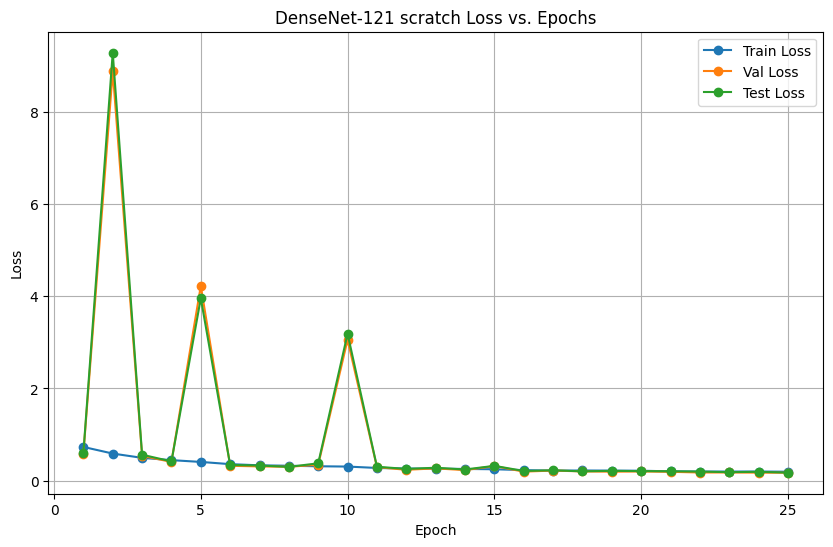

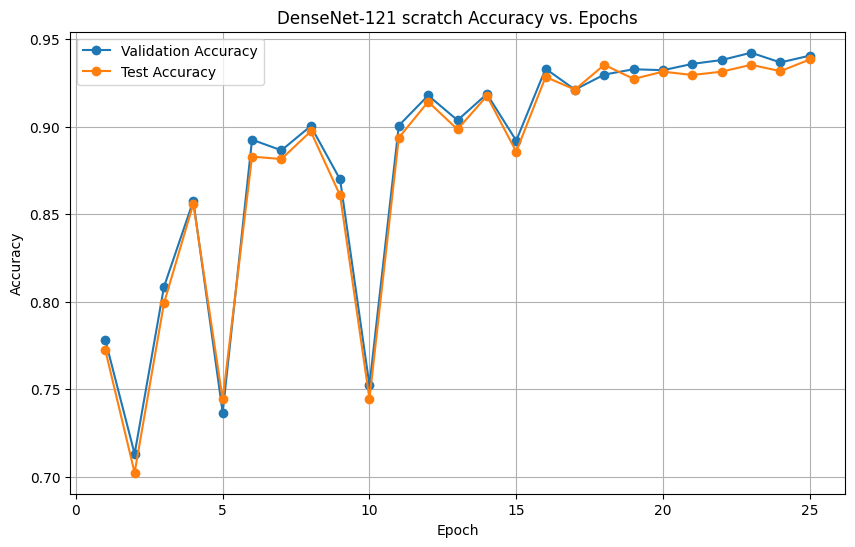

In [37]:
# --- Plot 1: Loss ---
loss_plots = [train_loss_resnet, val_loss_resnet, test_loss_resnet]
loss_labels = ["Train Loss", "Val Loss", "Test Loss"]
graph_vals(loss_plots, loss_labels, "DenseNet-121 scratch Loss vs. Epochs", "Epoch", "Loss")

# --- Plot 2: Accuracy ---
acc_plots = [val_acc_resnet, test_acc_resnet]
acc_labels = ["Validation Accuracy", "Test Accuracy"]
graph_vals(acc_plots, acc_labels, "DenseNet-121 scratch Accuracy vs. Epochs", "Epoch", "Accuracy")

In [25]:

# --- Configuration ---
LEARNING_RATE = 0.01  # Keep the stable rate
NUM_EPOCHS = 50
# ---------------------

# --- Weight Initialization Function ---
def weights_init(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, 0, 0.01)
        nn.init.constant_(m.bias, 0)

if NUM_CLASSES == 0:
    print("!! ERROR: NUM_CLASSES is 0. Please run the DataLoader cell first. !!")
else:
    # 1. Load GoogLeNet structure FROM SCRATCH
    # We set aux_logits=False so it returns a single output like the other models
    resnet_auto = torchvision.models.googlenet(
        weights=None, 
        aux_logits=False, 
        num_classes=NUM_CLASSES
    )

    # 2. Customize Input Layer for 1-Channel
    if COLOR_CHANNELS == 1:
        print(f"Customizing GoogLeNet for {COLOR_CHANNELS}-channel input.")
        
        # In GoogLeNet, conv1 is a 'BasicConv2d' block. 
        # The actual Conv2d layer is inside it at '.conv'
        original_layer = resnet_auto.conv1.conv
        
        # Create new 1-channel layer
        resnet_auto.conv1.conv = nn.Conv2d(
            1, # in_channels
            original_layer.out_channels, 
            kernel_size=original_layer.kernel_size, 
            stride=original_layer.stride, 
            padding=original_layer.padding, 
            bias=False
        )

    # 3. Apply Kaiming He Initialization
    print("Applying Kaiming He weight initialization...")
    resnet_auto.apply(weights_init)
    
    resnet_auto = resnet_auto.to(device) 

    print(f"Training GoogLeNet (from scratch) for {NUM_CLASSES} classes on {COLOR_CHANNELS}-channel images.")

    # 4. Train the model
    (
        train_loss_resnet, 
        val_loss_resnet, 
        val_acc_resnet, 
        test_loss_resnet,
        test_acc_resnet
    ) = train_model_resnet(
        resnet_auto,
        trainloader, 
        valloader, 
        testloader,
        num_epochs=NUM_EPOCHS, 
        lr=LEARNING_RATE
    )

    print("Training complete.")
    save_model("Scratch_GoogLeNet_50Epochs", DATA_ROOT, resnet_auto, full_dataset.classes, NUM_CLASSES, COLOR_CHANNELS)

Customizing GoogLeNet for 1-channel input.
Applying Kaiming He weight initialization...
Training GoogLeNet (from scratch) for 4 classes on 1-channel images.
Epoch 1/50 | Train Loss: 0.6923 | Train Acc: 0.7478 | Val Loss: 0.5211 | Val Acc: 0.8005 | Test Loss: 0.5265 | Test Acc: 0.7992 | LR: 0.010000
Epoch 2/50 | Train Loss: 0.4904 | Train Acc: 0.8136 | Val Loss: 0.4337 | Val Acc: 0.8438 | Test Loss: 0.4343 | Test Acc: 0.8438 | LR: 0.010000
Epoch 3/50 | Train Loss: 0.4250 | Train Acc: 0.8448 | Val Loss: 0.4025 | Val Acc: 0.8546 | Test Loss: 0.3993 | Test Acc: 0.8510 | LR: 0.010000
Epoch 4/50 | Train Loss: 0.3834 | Train Acc: 0.8595 | Val Loss: 0.4988 | Val Acc: 0.8185 | Test Loss: 0.5038 | Test Acc: 0.8211 | LR: 0.010000
Epoch 5/50 | Train Loss: 0.3477 | Train Acc: 0.8721 | Val Loss: 0.3782 | Val Acc: 0.8671 | Test Loss: 0.3742 | Test Acc: 0.8688 | LR: 0.005000
Epoch 6/50 | Train Loss: 0.3091 | Train Acc: 0.8892 | Val Loss: 0.3111 | Val Acc: 0.8907 | Test Loss: 0.3052 | Test Acc: 0.8893 

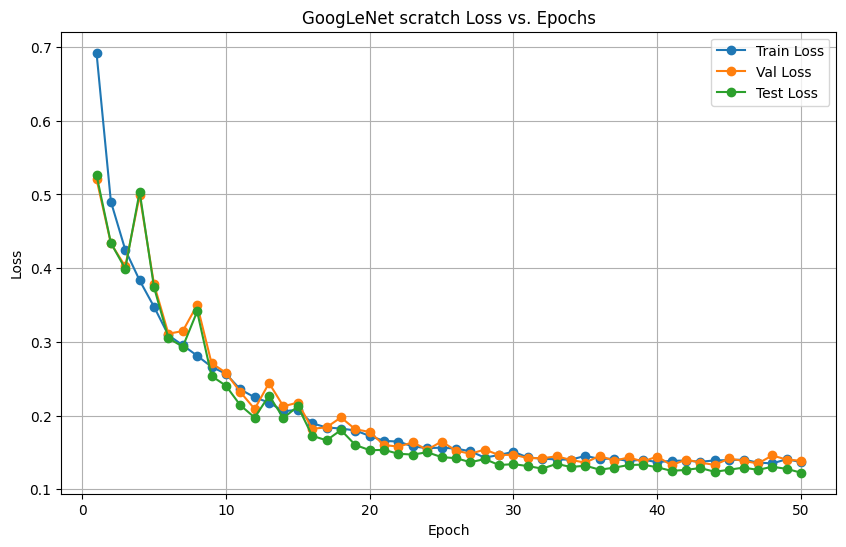

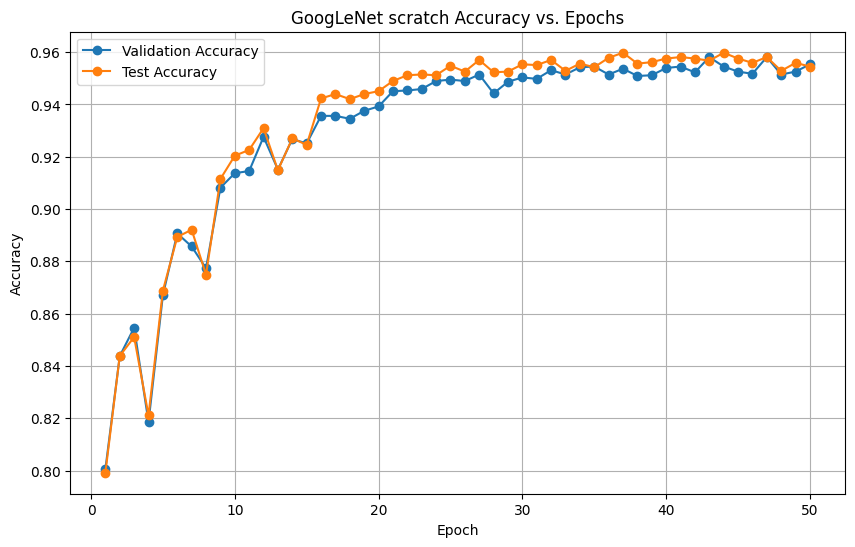

In [26]:
# --- Plot 1: Loss ---
loss_plots = [train_loss_resnet, val_loss_resnet, test_loss_resnet]
loss_labels = ["Train Loss", "Val Loss", "Test Loss"]
graph_vals(loss_plots, loss_labels, "GoogLeNet scratch Loss vs. Epochs", "Epoch", "Loss")

# --- Plot 2: Accuracy ---
acc_plots = [val_acc_resnet, test_acc_resnet]
acc_labels = ["Validation Accuracy", "Test Accuracy"]
graph_vals(acc_plots, acc_labels, "GoogLeNet scratch Accuracy vs. Epochs", "Epoch", "Accuracy")

In [14]:
# --- Configuration ---
LEARNING_RATE = 0.01 
NUM_EPOCHS = 25
# ---------------------

# --- Weight Initialization Function ---
def weights_init(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, 0, 0.01)
        nn.init.constant_(m.bias, 0)

if NUM_CLASSES == 0:
    print("!! ERROR: NUM_CLASSES is 0. Please run the DataLoader cell first. !!")
else:
    # 1. Load VGG16_BN structure FROM SCRATCH
    # We use vgg16_bn (Batch Norm) because it converges much faster/easier 
    # than standard vgg16 when training from scratch.
    resnet_auto = torchvision.models.vgg16_bn(weights=None)

    # 2. Customize Input Layer for 1-Channel
    if COLOR_CHANNELS == 1:
        print(f"Customizing VGG16_BN for {COLOR_CHANNELS}-channel input.")
        
        # In VGG, the first layer is the first item in the 'features' Sequential block
        original_conv = resnet_auto.features[0]
        
        # Create new 1-channel layer
        resnet_auto.features[0] = nn.Conv2d(
            1, # in_channels
            original_conv.out_channels, 
            kernel_size=original_conv.kernel_size, 
            stride=original_conv.stride, 
            padding=original_conv.padding, 
            bias=False
        )

    # 3. Customize Final Layer
    # In VGG, the classifier is a Sequential block. The final Linear layer is at index 6.
    num_ftrs = resnet_auto.classifier[6].in_features
    resnet_auto.classifier[6] = nn.Linear(num_ftrs, NUM_CLASSES)
    
    # 4. Apply Kaiming He Initialization
    print("Applying Kaiming He weight initialization...")
    resnet_auto.apply(weights_init)
    
    resnet_auto = resnet_auto.to(device) 

    print(f"Training VGG16_BN (from scratch) for {NUM_CLASSES} classes on {COLOR_CHANNELS}-channel images.")

    # 5. Train the model
    (
        train_loss_resnet, 
        val_loss_resnet, 
        val_acc_resnet, 
        test_loss_resnet,
        test_acc_resnet
    ) = train_model_resnet(
        resnet_auto,
        trainloader, 
        valloader, 
        testloader,
        num_epochs=NUM_EPOCHS, 
        lr=LEARNING_RATE
    )

    print("Training complete.")
    save_model("Scratch_VGG16_BN", DATA_ROOT, resnet_auto, full_dataset.classes, NUM_CLASSES, COLOR_CHANNELS)

Customizing VGG16_BN for 1-channel input.
Applying Kaiming He weight initialization...
Training VGG16_BN (from scratch) for 4 classes on 1-channel images.
Epoch 1/25 | Train Loss: 0.8466 | Train Acc: 0.7174 | Val Loss: 0.6228 | Val Acc: 0.7827 | Test Loss: 0.6299 | Test Acc: 0.7745 | LR: 0.010000
Epoch 2/25 | Train Loss: 0.6449 | Train Acc: 0.7635 | Val Loss: 0.5252 | Val Acc: 0.7825 | Test Loss: 0.5275 | Test Acc: 0.7709 | LR: 0.010000
Epoch 3/25 | Train Loss: 0.5445 | Train Acc: 0.7980 | Val Loss: 0.5340 | Val Acc: 0.8088 | Test Loss: 0.5396 | Test Acc: 0.7947 | LR: 0.010000
Epoch 4/25 | Train Loss: 0.4826 | Train Acc: 0.8211 | Val Loss: 0.4188 | Val Acc: 0.8463 | Test Loss: 0.4234 | Test Acc: 0.8399 | LR: 0.010000
Epoch 5/25 | Train Loss: 0.4375 | Train Acc: 0.8391 | Val Loss: 0.6186 | Val Acc: 0.8058 | Test Loss: 0.6488 | Test Acc: 0.7922 | LR: 0.005000
Epoch 6/25 | Train Loss: 0.3818 | Train Acc: 0.8599 | Val Loss: 0.4131 | Val Acc: 0.8621 | Test Loss: 0.4273 | Test Acc: 0.8513 | 

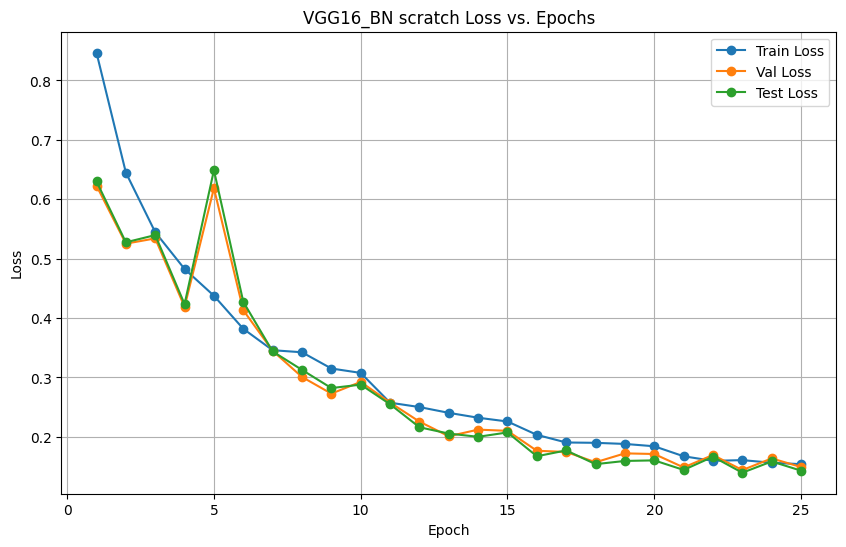

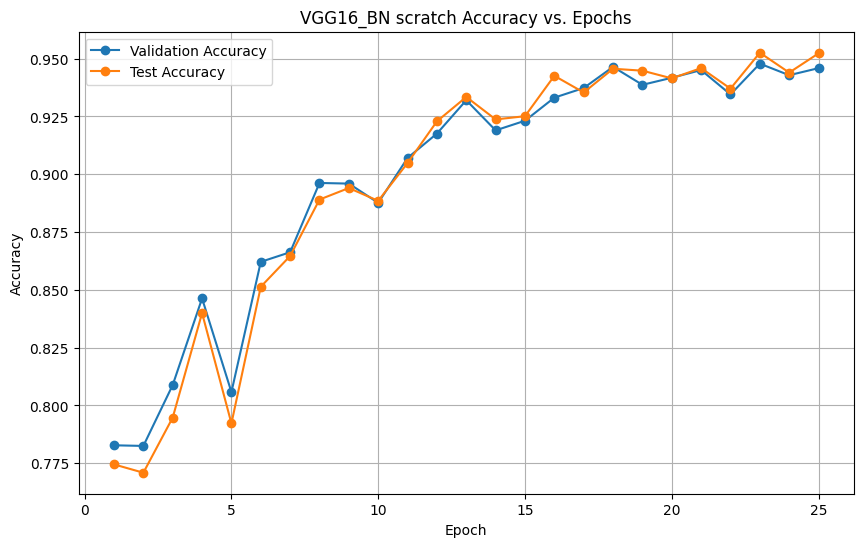

In [15]:
# --- Plot 1: Loss ---
loss_plots = [train_loss_resnet, val_loss_resnet, test_loss_resnet]
loss_labels = ["Train Loss", "Val Loss", "Test Loss"]
graph_vals(loss_plots, loss_labels, "VGG16_BN scratch Loss vs. Epochs", "Epoch", "Loss")

# --- Plot 2: Accuracy ---
acc_plots = [val_acc_resnet, test_acc_resnet]
acc_labels = ["Validation Accuracy", "Test Accuracy"]
graph_vals(acc_plots, acc_labels, "VGG16_BN scratch Accuracy vs. Epochs", "Epoch", "Accuracy")